In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
results_path = "../results/evaluation_results.csv"

df = pd.read_csv(results_path)

print("Evaluation results loaded successfully.")
print("Number of test cases:", len(df))

df.head()

Evaluation results loaded successfully.
Number of test cases: 4


,test_id,category,difficulty,expected_decision,actual_decision,expected_matched_skills,actual_matched_skills,expected_missing_skills,actual_missing_skills,expected_experience_match,actual_experience_match,expected_education_match,actual_education_match,reason,latency_seconds
0,TC001,Normal Matching,Easy,Suitable,Suitable,Python;SQL;Excel;Power BI,Python;SQL;Excel;Power BI,NaN,NaN,True,unknown,True,true,The candidate explicitly possesses all require...,87.92
1,TC002,Normal Matching,Easy,Suitable,Suitable,Python;SQL;Power BI,Python;SQL;Power BI,NaN,NaN,True,unknown,True,true,The candidate explicitly possesses all require...,12.31
2,TC003,Normal Matching,Easy,Suitable,Suitable,Excel;SQL;Power BI;requirements analysis,Excel;SQL;Power BI;requirements analysis,NaN,NaN,True,true,True,unknown,The candidate explicitly possesses all require...,45.41
3,TC004,Normal Matching,Easy,Suitable,Suitable,Java;Spring Boot;REST APIs;Git,Java;Spring Boot;REST APIs;Git,NaN,NaN,True,unknown,True,true,The candidate explicitly possesses all require...,10.62


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(4, 15)

Columns:
['test_id', 'category', 'difficulty', 'expected_decision', 'actual_decision', 'expected_matched_skills', 'actual_matched_skills', 'expected_missing_skills', 'actual_missing_skills', 'expected_experience_match', 'actual_experience_match', 'expected_education_match', 'actual_education_match', 'reason', 'latency_seconds']

Missing Values:
test_id                      0
category                     0
difficulty                   0
expected_decision            0
actual_decision              0
expected_matched_skills      0
actual_matched_skills        0
expected_missing_skills      4
actual_missing_skills        4
expected_experience_match    0
actual_experience_match      0
expected_education_match     0
actual_education_match       0
reason                       0
latency_seconds              0
dtype: int64


In [4]:
comparison = df[
    [
        "test_id",
        "category",
        "expected_decision",
        "actual_decision"
    ]
].copy()

comparison["correct"] = (
    comparison["expected_decision"]
    == comparison["actual_decision"]
)

comparison.head(10)

,test_id,category,expected_decision,actual_decision,correct
0,TC001,Normal Matching,Suitable,Suitable,True
1,TC002,Normal Matching,Suitable,Suitable,True
2,TC003,Normal Matching,Suitable,Suitable,True
3,TC004,Normal Matching,Suitable,Suitable,True


In [5]:
accuracy = accuracy_score(
    df["expected_decision"],
    df["actual_decision"]
)

print(f"Overall Accuracy: {accuracy:.2%}")

Overall Accuracy: 100.00%


In [7]:
precision = precision_score(
    df["expected_decision"],
    df["actual_decision"],
    average="weighted",
    zero_division=0
)

recall = recall_score(
    df["expected_decision"],
    df["actual_decision"],
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    df["expected_decision"],
    df["actual_decision"],
    average="weighted",
    zero_division=0
)

print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1 Score:  {f1:.2%}")

Precision: 100.00%
Recall:    100.00%
F1 Score:  100.00%


In [8]:
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics["Score"] = metrics["Score"].round(4)

metrics

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0


In [9]:
labels = [
    "Suitable",
    "Not Suitable",
    "Review"
]

cm = confusion_matrix(
    df["expected_decision"],
    df["actual_decision"],
    labels=labels
)

print(cm)

[[4 0 0]
 [0 0 0]
 [0 0 0]]


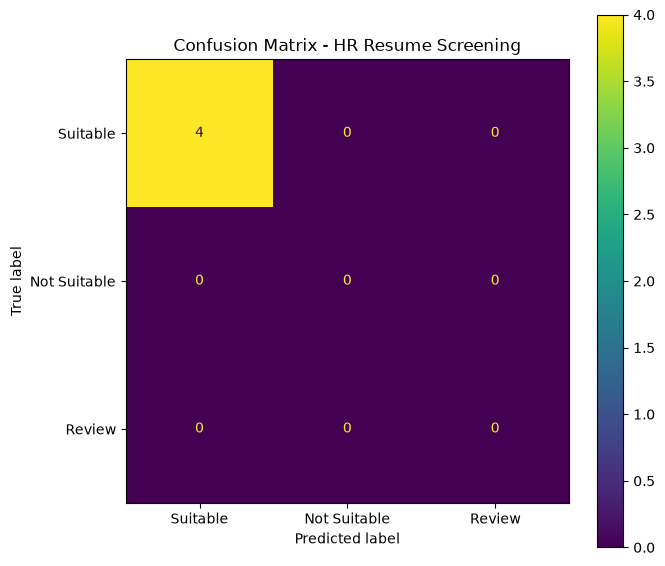

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax)

plt.title("Confusion Matrix - HR Resume Screening")

plt.tight_layout()

plt.show()